In [21]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz, plot_tree
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [4]:
iris = load_iris()
X = iris.data[:,2:] ; y = iris.target

In [5]:
clf_tree = DecisionTreeClassifier(max_depth=3)
clf_tree.fit(X,y)

DecisionTreeClassifier(max_depth=3)

### Plotting tree

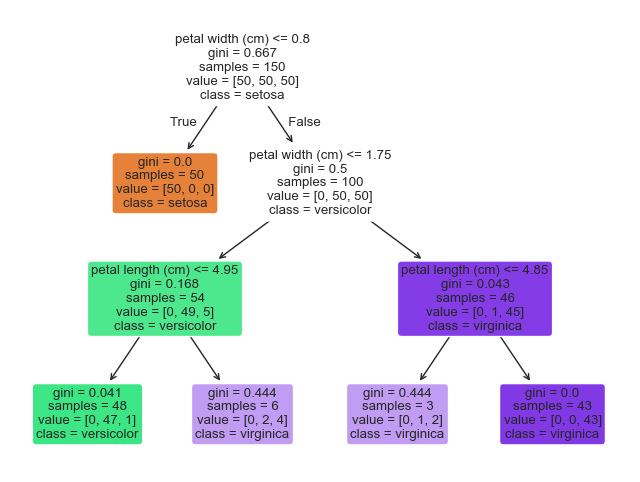

In [16]:
plt.figure(figsize=(8,6))
plot_tree(clf_tree,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.show()

### tree explaination

Goal: classify iris flower. Input features: petal length and width. 
- root node (depth 0): this node ask whether the flower petal width is smaller than 0.8cm. If yes, it moves to the corresponding child's node (depth 1, left) or the left leaf node. 
- Leaf node (depth 1): signify the final prediction of tree, which in this case classify them as setosa flower. 
    - to be setosa means that the petal width should be lower than 0.8cm, regardless of the petal length
- childs node (depth 1): if a flower has a petal width longer than 0.8cm (not setosa), the algorithm enlarges the criteria of petal width for further consideration.
- childs node (depth 2 & 3): If the petal width is larger than 1.75cm the algorithm classify the flower as a virginica (both leaf node of this child's node assign virginica).  In contrast, the algorithm asks further whether the petal length of a flower is smaller than 4.95cm. If true, then the flower is most likely a versicolor. If not, its likely to be a virginica. 

### Plotting The Decision Boundaries

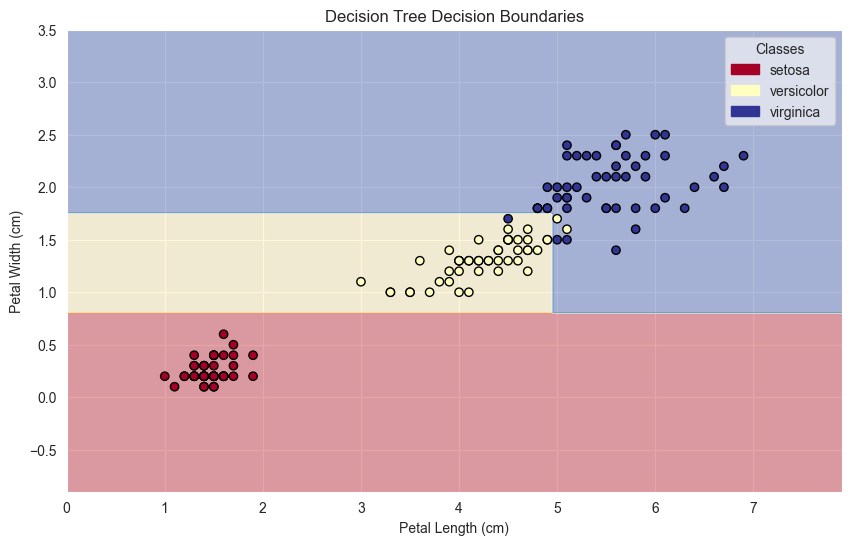

In [25]:
target_names = iris.target_names

## define max & min boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

## create x & y points
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

## Predict on the grid
Z = clf_tree.predict(grid)
Z = Z.reshape(xx.shape)

## Plot
plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)

# Customize legend
colors = [plt.cm.RdYlBu(i / 2) for i in range(3)]  # 3 classes
legend_patches = [Patch(color=colors[i], label=target_names[i]) for i in range(3)]
plt.legend(handles=legend_patches, title="Classes")

## extras
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Tree Decision Boundaries")

plt.show()